# SVM + SMOTEENN

In [2]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("..\\datasets_paralelos\\kmeans_5clusters.csv")

In [4]:
# 2. Separar X e y
X = df.drop(columns=['cluster'])
Y = df['cluster']

In [5]:
# 3. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))  # multiclasse suportado automaticamente
])

In [7]:
# 5. Cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

Acurácias de cross-validation: [0.98357921 0.98287671 0.98349139 0.98296452 0.98208641]
Média da acurácia de cross-validation: 0.9829996487530736


In [8]:
# 6. Treinar o pipeline completo no treino
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smoteenn', SMOTEENN(random_state=42)), ('svm', SVC())])

In [9]:
# 7. Avaliar no treino
y_train_pred = pipeline.predict(X_train)
print('Métricas de Classificação para o conjunto de treino:')
print(classification_report(y_train, y_train_pred))

Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     16691
           1       0.98      1.00      0.99      4629
           2       0.98      0.99      0.99     13014
           3       0.99      0.98      0.99     15504
           4       0.97      0.99      0.98      7102

    accuracy                           0.99     56940
   macro avg       0.98      0.99      0.99     56940
weighted avg       0.99      0.99      0.99     56940



In [10]:
# 8. Avaliar no teste
y_test_pred = pipeline.predict(X_test)
print("Métricas de Classificação para o conjunto de teste:")
print(classification_report(y_test, y_test_pred))

Métricas de Classificação para o conjunto de teste:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7153
           1       0.97      1.00      0.99      1984
           2       0.97      0.99      0.98      5578
           3       0.99      0.98      0.98      6645
           4       0.97      0.99      0.98      3043

    accuracy                           0.98     24403
   macro avg       0.98      0.99      0.98     24403
weighted avg       0.98      0.98      0.98     24403



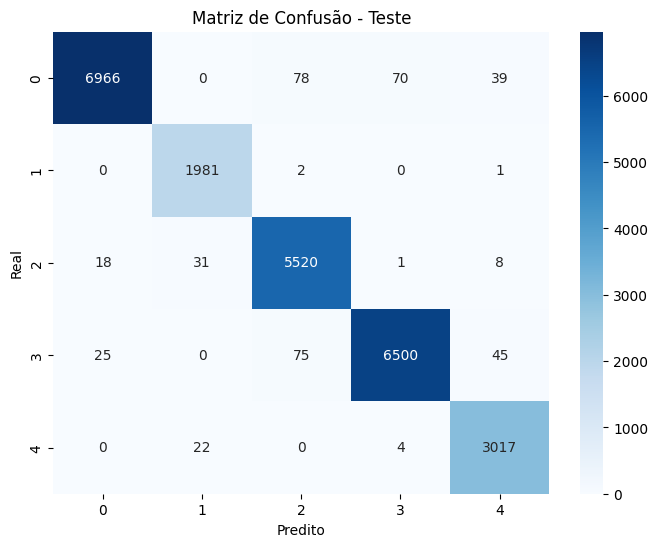

In [11]:
# 9. Matriz de confusão do teste
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Teste')
plt.show()

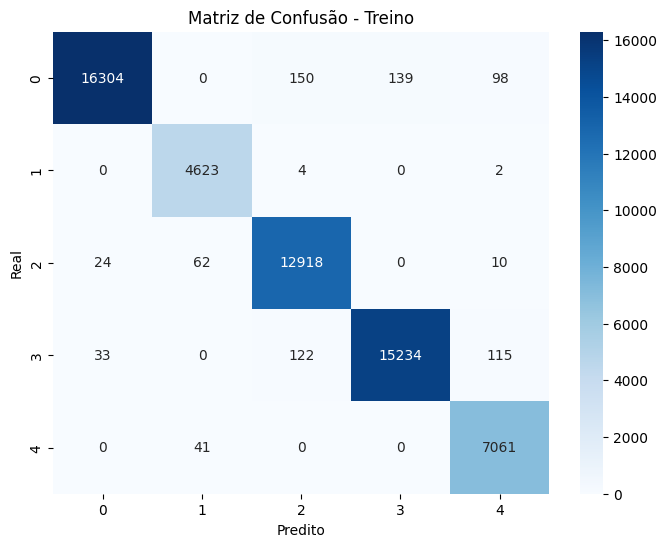

In [12]:

# Matriz de Confusão para o conjunto de treino
conf_matrix = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Treino')
plt.show()

